In [29]:
import numpy as np
import torch

class CurriculumScheduler:
    def __init__(self, total_steps, a, b, scheduler_name):
        self.total_steps = total_steps
        self.a = a
        self.b = b
        self.scheduler_name = scheduler_name
        
    def get_current_value(self, current_step):
        if self.scheduler_name == 'log':
            value = self.g_log(current_step)
        elif self.scheduler_name == 'exp':
            value = self.g_exp(current_step)
        elif self.scheduler_name == 'linear':
            value = self.g_linear(current_step)
        elif self.scheduler_name == 'polynomial':
            value = self.g_quad(current_step)
        else:
            raise ValueError(f"Unknown scheduler name: {self.scheduler_name}")
        
        return min(value, 1.0)
        
    def g_exp(self,t):  # Exponential
        return self.b + ((1-self.b)/(np.exp(10)-1)) * (np.exp(10*t/(self.a*self.total_steps)) - 1)

    def g_log(self,t):  # Logarithmic
        return self.b + (1-self.b)*(1 + 0.1*np.log(t/(self.a*self.total_steps) + np.exp(-10)))

    def g_linear(self,t):  # Linear
        return self.b + (1-self.b)*(t/(self.a * self.total_steps))

    def g_quad(self,t):  # Quadratic
        return self.b + (1-self.b)*(t/(self.a* self.total_steps))**2

    


{'log': [0.2, 0.4370376670972455, 0.4903956718211376, 0.5221226001599817, 0.5447796468828296, 0.5624158501026104, 0.5768577315345227, 0.5890868822618738, 0.5996921289702684, 0.6090546254212517, 0.6174353169731199, 0.6250207145810345, 0.6319487625845037, 0.6383243622114487, 0.6442291491512939, 0.6497279023953993, 0.6548728877861565, 0.6597068868076081, 0.6642653610387219, 0.6685780323462921, 0.6726700584168706, 0.6765629219446454, 0.680275113300888, 0.6838226616969563, 0.6872195534808268, 0.690478065177256, 0.6936090313095487, 0.6966220617529062, 0.6995257196184191, 0.7023276679678536, 0.7050347916917794, 0.7076532994316234, 0.7101888093427109, 0.7126464216783199, 0.715030780552679, 0.7173461267628694, 0.7195963431792567, 0.7217849939248191, 0.7239153583361595, 0.7259904605186396, 0.7280130951642334, 0.7299858501852403, 0.7319111266237797, 0.7337911562213018, 0.7356280169705767, 0.7374236469219386, 0.7391798564737881, 0.7408983393427593, 0.7425806823801853, 0.7442283743774669, 0.7458428

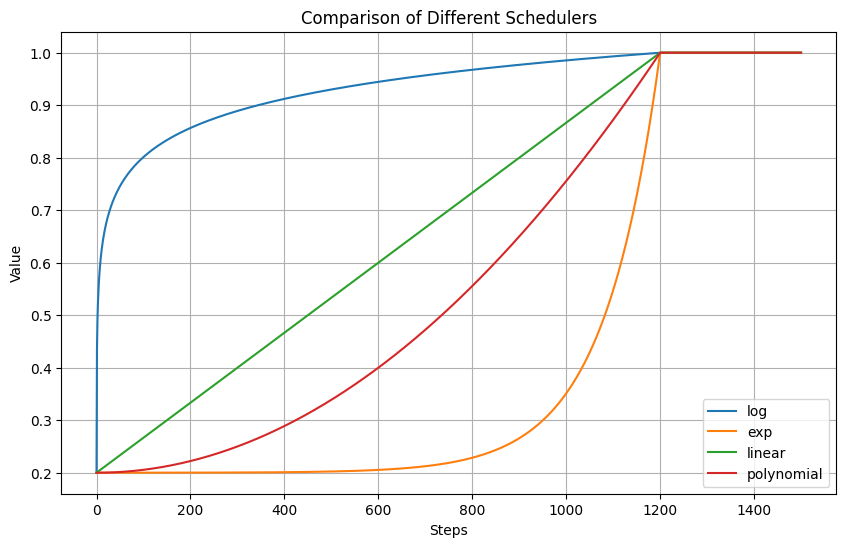

In [33]:

total_steps = 1500
a =0.8
b =0.2
import matplotlib.pyplot as plt
scheduler_names = ['log','exp','linear','polynomial'] #, 'exp', 'linear', 'polynomial']
steps = np.arange(0, total_steps + 1)
values = {}

for name in scheduler_names:
    scheduler = CurriculumScheduler(total_steps, a, b, name)
    values[name] = [scheduler.get_current_value(step) for step in steps]
print(values)

plt.figure(figsize=(10, 6))
for name in scheduler_names:
    plt.plot(steps, values[name], label=name)

plt.xlabel('Steps')
plt.ylabel('Value')
plt.title('Comparison of Different Schedulers')
plt.legend()
plt.grid()
plt.show()

In [14]:
0.2 + 0.8 * (1 + 0.1 * np.log2(1/(0.8* 100) + 1e-10))

0.49424575333233584

In [37]:
num_bins = 5
max_feature_dim = 100
min_feature_dim = 2

bin_size = (max_feature_dim - min_feature_dim) // num_bins
bin_ranges = [(min_feature_dim + i * bin_size, 
    min_feature_dim + (i + 1) * bin_size) for i in range(num_bins)]
bin_ranges[-1] = (bin_ranges[-1][0], max_feature_dim + 1)  # Create a new tuple to replace the last bin

In [39]:
bin_ranges
model_names_list= ['gmm', 'scm-prob', 'scm-contextual','copula']

In [40]:
categories = [(bin_range, model_name) for bin_range in bin_ranges for model_name in model_names_list]
print(categories)
        

[((2, 21), 'gmm'), ((2, 21), 'scm-prob'), ((2, 21), 'scm-contextual'), ((2, 21), 'copula'), ((21, 40), 'gmm'), ((21, 40), 'scm-prob'), ((21, 40), 'scm-contextual'), ((21, 40), 'copula'), ((40, 59), 'gmm'), ((40, 59), 'scm-prob'), ((40, 59), 'scm-contextual'), ((40, 59), 'copula'), ((59, 78), 'gmm'), ((59, 78), 'scm-prob'), ((59, 78), 'scm-contextual'), ((59, 78), 'copula'), ((78, 101), 'gmm'), ((78, 101), 'scm-prob'), ((78, 101), 'scm-contextual'), ((78, 101), 'copula')]
